# Analyse Metier par Produit, Gaspillage et Destructions

Ce notebook complete l'analyse exploratoire generale en se concentrant sur les enjeux metier du dataset enrichi : volumes consommes, destructions, taux de gaspillage, produits a risque et tendances temporelles.

## Objectifs
- comparer les produits entre eux sur des indicateurs metier
- identifier les produits qui generent le plus de destruction
- mesurer les taux de gaspillage et les produits a surveiller
- suivre l'evolution des destructions dans le temps
- faire un focus detaille sur un produit particulier

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', palette='deep')

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATASET_PATH = PROJECT_ROOT / 'data' / 'dataset_stock_hopital_ENRICHI.csv'

PRODUIT_FOCUS = 'Poulet frais'
MIN_VOLUME_SORTIE = 300
TOP_N = 15

print(f'Produit focus: {PRODUIT_FOCUS}')

Project root : C:\Users\mxmle\project\final-project
Dataset path : C:\Users\mxmle\project\final-project\data\dataset_stock_hopital_ENRICHI.csv
Produit focus: Poulet frais
Exists       : True


In [5]:
df = pd.read_csv(DATASET_PATH)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
if 'date_expiration' in df.columns:
    df['date_expiration'] = pd.to_datetime(df['date_expiration'], errors='coerce')

required_columns = ['date', 'nom_produit', 'quantite', 'type_operation', 'type_sortie']
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f'Colonnes manquantes: {missing_columns}')

df['quantite'] = pd.to_numeric(df['quantite'], errors='coerce').fillna(0)
df['delai_expiration_jours'] = (df['date_expiration'] - df['date']).dt.days if 'date_expiration' in df.columns else np.nan

sorties = df[df['type_operation'].eq('SORTIE')].copy()
consommation = sorties[sorties['type_sortie'].eq('CONSOMMATION')].copy()
destruction = sorties[sorties['type_sortie'].eq('DESTRUCTION')].copy()
entrees = df[df['type_operation'].eq('ENTREE')].copy()

print(f'Lignes dataset      : {len(df):,}')
print(f'Lignes sorties      : {len(sorties):,}')
print(f'Lignes consommation : {len(consommation):,}')
print(f'Lignes destruction  : {len(destruction):,}')
print(f'Lignes entrees      : {len(entrees):,}')

Lignes dataset      : 85,809
Lignes sorties      : 71,837
Lignes consommation : 62,576
Lignes destruction  : 9,261
Lignes entrees      : 13,972


## 1. Vue metier globale

In [6]:
global_summary = pd.DataFrame({
    'indicateur': [
        'Produits uniques',
        'Quantite totale entree',
        'Quantite totale consommation',
        'Quantite totale destruction',
        'Taux global de destruction'
    ],
    'valeur': [
        df['nom_produit'].nunique(),
        entrees['quantite'].sum(),
        consommation['quantite'].sum(),
        destruction['quantite'].sum(),
        destruction['quantite'].sum() / max(consommation['quantite'].sum() + destruction['quantite'].sum(), 1)
    ]
})

display(global_summary)

,indicateur,valeur
0,Produits uniques,40.000000
1,Quantite totale entree,887599.700000
2,Quantite totale consommation,733165.400000
3,Quantite totale destruction,150962.110000
4,Taux global de destruction,0.170747


,type_sortie,quantite
0,CONSOMMATION,733165.40
1,DESTRUCTION,150962.11


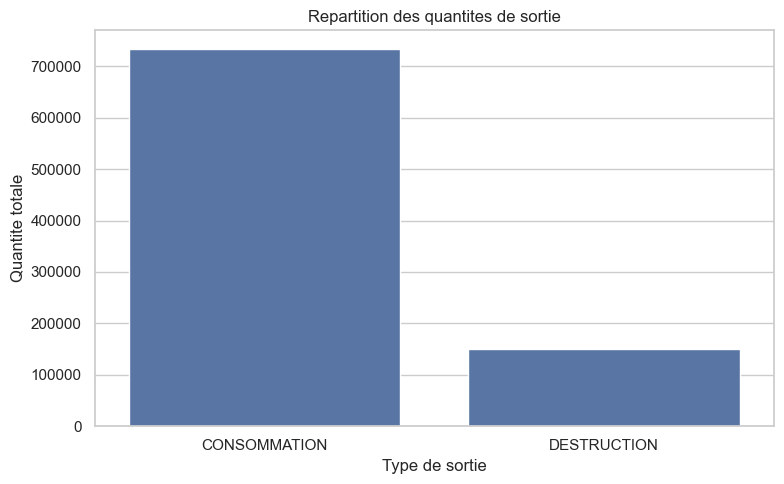

In [7]:
mix_sorties = sorties.groupby('type_sortie')['quantite'].sum().sort_values(ascending=False).reset_index()
display(mix_sorties)

plt.figure(figsize=(8, 5))
sns.barplot(data=mix_sorties, x='type_sortie', y='quantite')
plt.title('Repartition des quantites de sortie')
plt.xlabel('Type de sortie')
plt.ylabel('Quantite totale')
plt.tight_layout()
plt.show()

## 2. Indicateurs metier par produit

In [8]:
consumption_by_product = consommation.groupby('nom_produit')['quantite'].sum().rename('consommation_totale')
destruction_by_product = destruction.groupby('nom_produit')['quantite'].sum().rename('destruction_totale')
entries_by_product = entrees.groupby('nom_produit')['quantite'].sum().rename('entree_totale')
active_days = sorties.groupby('nom_produit')['date'].nunique().rename('jours_actifs_sortie')
avg_stock = df.groupby('nom_produit')['stock_theorique'].mean().rename('stock_moyen') if 'stock_theorique' in df.columns else pd.Series(dtype=float)
median_dlc = df.groupby('nom_produit')['delai_expiration_jours'].median().rename('dlc_mediane_jours')

product_kpis = pd.concat([
    consumption_by_product,
    destruction_by_product,
    entries_by_product,
    active_days,
    avg_stock,
    median_dlc
], axis=1).fillna(0)

product_kpis['sortie_totale'] = product_kpis['consommation_totale'] + product_kpis['destruction_totale']
product_kpis['taux_destruction'] = product_kpis['destruction_totale'] / product_kpis['sortie_totale'].replace(0, np.nan)
product_kpis['conso_moyenne_jour_active'] = product_kpis['consommation_totale'] / product_kpis['jours_actifs_sortie'].replace(0, np.nan)
product_kpis = product_kpis.sort_values('destruction_totale', ascending=False).round(2)

display(product_kpis.head(TOP_N))

,consommation_totale,destruction_totale,entree_totale,jours_actifs_sortie,stock_moyen,dlc_mediane_jours,sortie_totale,taux_destruction,conso_moyenne_jour_active
nom_produit,,,,,,,,,
Pain frais,13615.98,40589.26,54245.24,1822,22.63,1.0,54205.24,0.75,7.47
Poisson blanc,4779.27,20969.91,25769.18,1826,11.05,1.0,25749.18,0.81,2.62
Saumon frais,3443.55,15660.63,19119.18,1826,8.38,1.0,19104.18,0.82,1.89
Poulet frais,16126.43,11701.44,27844.39,1809,18.99,1.0,27827.87,0.42,8.91
Légumes frais,35264.17,10004.80,45360.00,1358,121.95,4.0,45268.97,0.22,25.97
Salade verte,13035.78,9739.48,22788.98,1812,15.70,1.0,22775.26,0.43,7.19
Viande hachée,12404.63,9321.84,21738.88,1810,15.21,1.0,21726.47,0.43,6.85
Fruits frais,29045.22,8487.60,37625.00,1409,103.58,4.0,37532.82,0.23,20.61
Tomates fraîches,10680.20,8246.29,18942.00,1453,19.89,2.0,18926.49,0.44,7.35


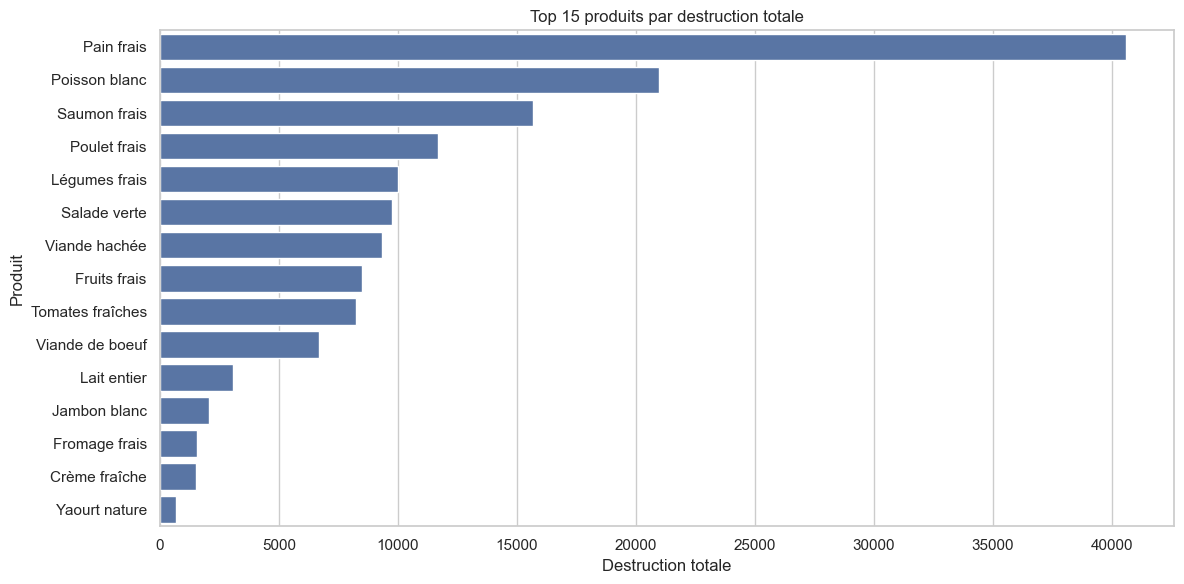

In [9]:
top_destruction = product_kpis.head(TOP_N).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_destruction, x='destruction_totale', y='nom_produit')
plt.title(f'Top {TOP_N} produits par destruction totale')
plt.xlabel('Destruction totale')
plt.ylabel('Produit')
plt.tight_layout()
plt.show()

,nom_produit,sortie_totale,destruction_totale,taux_destruction
0,Saumon frais,19104.18,15660.63,0.82
1,Poisson blanc,25749.18,20969.91,0.81
2,Pain frais,54205.24,40589.26,0.75
3,Tomates fraîches,18926.49,8246.29,0.44
4,Viande hachée,21726.47,9321.84,0.43
5,Salade verte,22775.26,9739.48,0.43
6,Poulet frais,27827.87,11701.44,0.42
7,Viande de boeuf,19615.31,6703.09,0.34
8,Fruits frais,37532.82,8487.60,0.23
9,Légumes frais,45268.97,10004.80,0.22


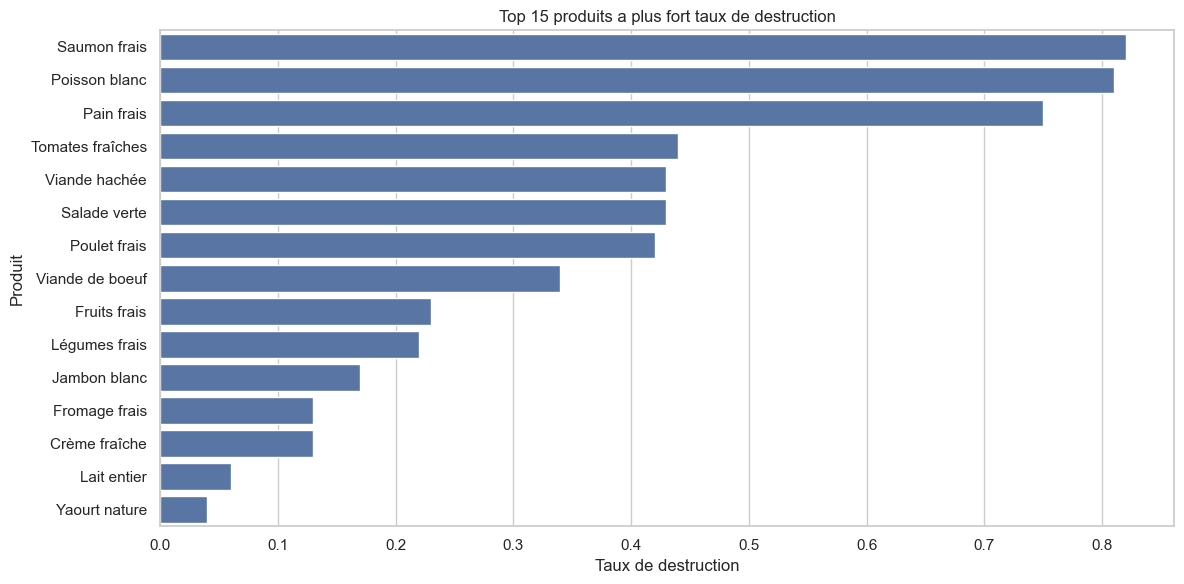

In [10]:
high_volume_products = product_kpis[product_kpis['sortie_totale'] >= MIN_VOLUME_SORTIE].copy()
high_volume_products = high_volume_products.sort_values('taux_destruction', ascending=False).head(TOP_N).reset_index()
display(high_volume_products[['nom_produit', 'sortie_totale', 'destruction_totale', 'taux_destruction']])

plt.figure(figsize=(12, 6))
sns.barplot(data=high_volume_products, x='taux_destruction', y='nom_produit')
plt.title(f'Top {TOP_N} produits a plus fort taux de destruction')
plt.xlabel('Taux de destruction')
plt.ylabel('Produit')
plt.tight_layout()
plt.show()

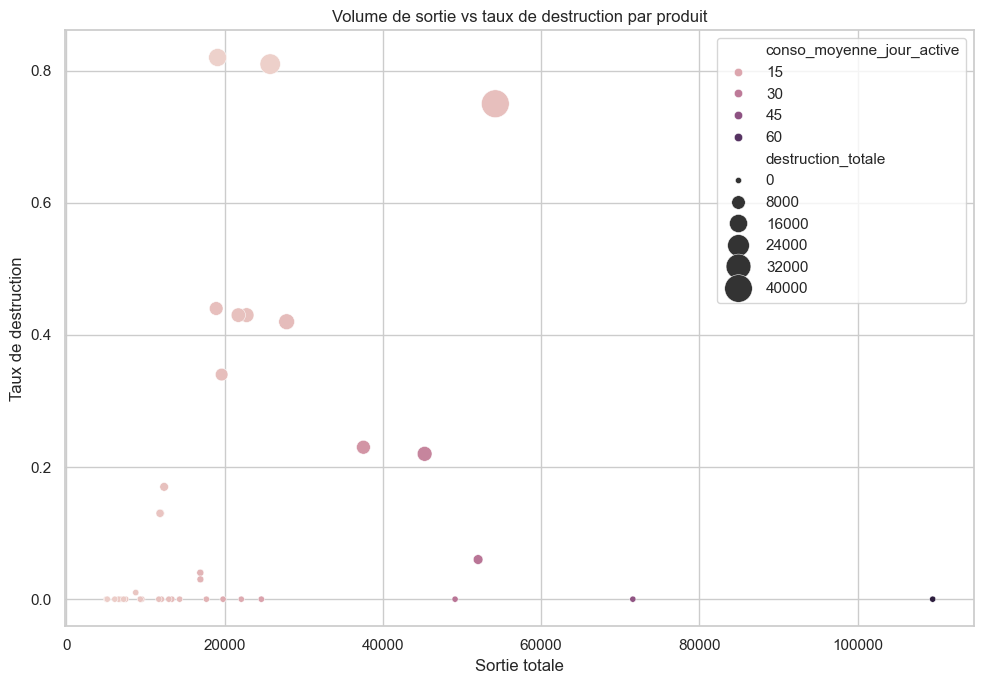

In [11]:
plt.figure(figsize=(10, 7))
scatter_df = product_kpis.replace([np.inf, -np.inf], np.nan).dropna(subset=['sortie_totale', 'taux_destruction'])
sns.scatterplot(
    data=scatter_df,
    x='sortie_totale',
    y='taux_destruction',
    size='destruction_totale',
    hue='conso_moyenne_jour_active',
    sizes=(20, 400)
)
plt.title('Volume de sortie vs taux de destruction par produit')
plt.xlabel('Sortie totale')
plt.ylabel('Taux de destruction')
plt.tight_layout()
plt.show()

## 3. Evolution temporelle du gaspillage

In [12]:
consumption_monthly = consommation.groupby(consommation['date'].dt.to_period('M'))['quantite'].sum().rename('consommation').reset_index()
destruction_monthly = destruction.groupby(destruction['date'].dt.to_period('M'))['quantite'].sum().rename('destruction').reset_index()
monthly = consumption_monthly.merge(destruction_monthly, on='date', how='outer').fillna(0)
monthly['date'] = monthly['date'].dt.to_timestamp()
monthly['taux_destruction'] = monthly['destruction'] / (monthly['consommation'] + monthly['destruction']).replace(0, np.nan)
display(monthly.tail(12))

,date,consommation,destruction,taux_destruction
48,2024-01-01,16144.78,1878.40,0.104221
49,2024-02-01,13569.09,2125.79,0.135445
50,2024-03-01,14346.58,2530.77,0.149951
51,2024-04-01,11788.74,2598.41,0.180606
52,2024-05-01,13464.77,2509.35,0.157088
53,2024-06-01,11535.81,2562.41,0.181754
54,2024-07-01,7244.30,3091.24,0.299088
55,2024-08-01,7201.46,3333.74,0.316438
56,2024-09-01,12391.39,2657.14,0.176571
57,2024-10-01,13919.32,2591.22,0.156943


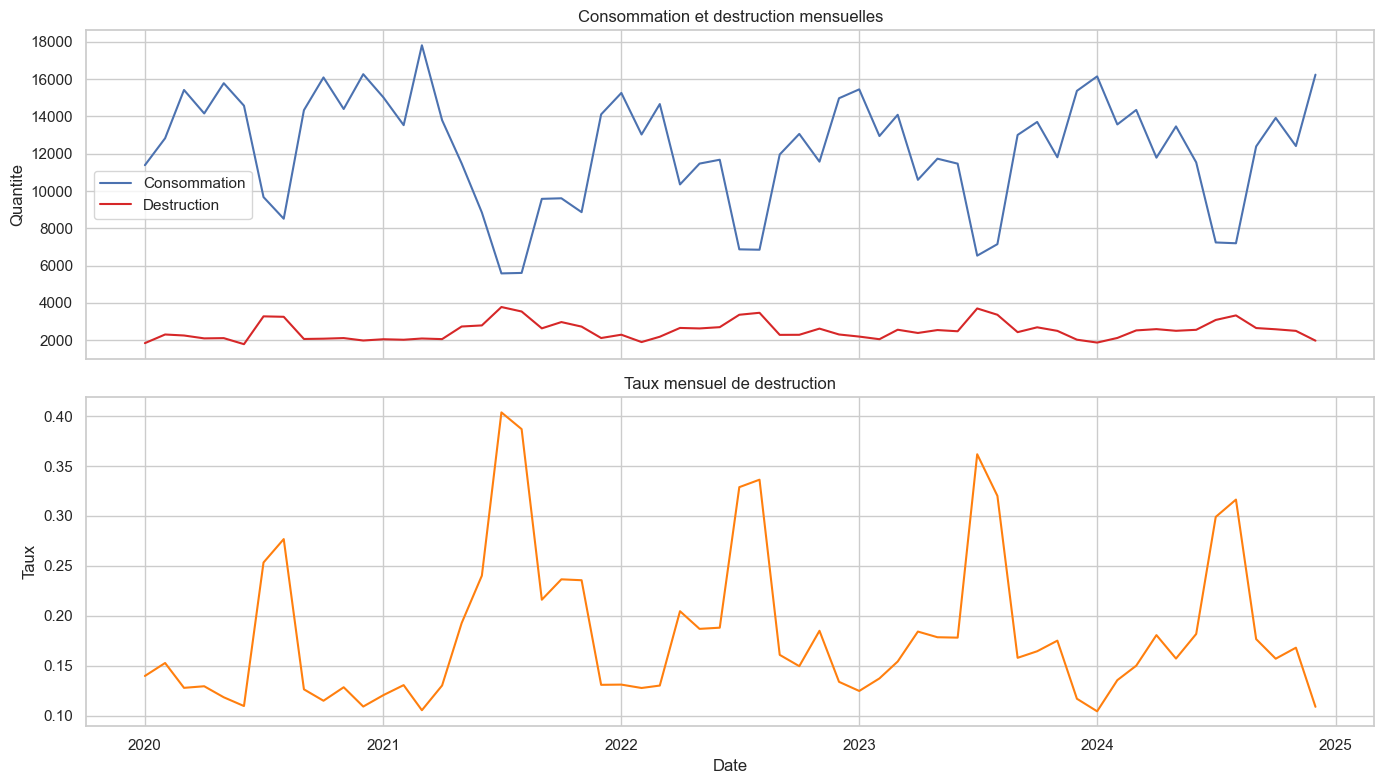

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
sns.lineplot(data=monthly, x='date', y='consommation', ax=axes[0], label='Consommation')
sns.lineplot(data=monthly, x='date', y='destruction', ax=axes[0], label='Destruction', color='tab:red')
axes[0].set_title('Consommation et destruction mensuelles')
axes[0].set_ylabel('Quantite')

sns.lineplot(data=monthly, x='date', y='taux_destruction', ax=axes[1], color='tab:orange')
axes[1].set_title('Taux mensuel de destruction')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Taux')

plt.tight_layout()
plt.show()

## 4. Focus sur un produit

In [14]:
produit_df = df[df['nom_produit'].eq(PRODUIT_FOCUS)].copy()
produit_sorties = sorties[sorties['nom_produit'].eq(PRODUIT_FOCUS)].copy()
produit_conso = consommation[consommation['nom_produit'].eq(PRODUIT_FOCUS)].copy()
produit_dest = destruction[destruction['nom_produit'].eq(PRODUIT_FOCUS)].copy()

if produit_df.empty:
    raise ValueError(f'Produit introuvable: {PRODUIT_FOCUS}')

focus_summary = pd.DataFrame({
    'indicateur': ['Quantite consommee', 'Quantite detruite', 'Taux destruction', 'Stock moyen', 'DLC mediane'],
    'valeur': [
        produit_conso['quantite'].sum(),
        produit_dest['quantite'].sum(),
        produit_dest['quantite'].sum() / max(produit_conso['quantite'].sum() + produit_dest['quantite'].sum(), 1),
        produit_df['stock_theorique'].mean() if 'stock_theorique' in produit_df.columns else np.nan,
        produit_df['delai_expiration_jours'].median()
    ]
})
display(focus_summary)

,indicateur,valeur
0,Quantite consommee,16126.430000
1,Quantite detruite,11701.440000
2,Taux destruction,0.420494
3,Stock moyen,18.986039
4,DLC mediane,1.000000


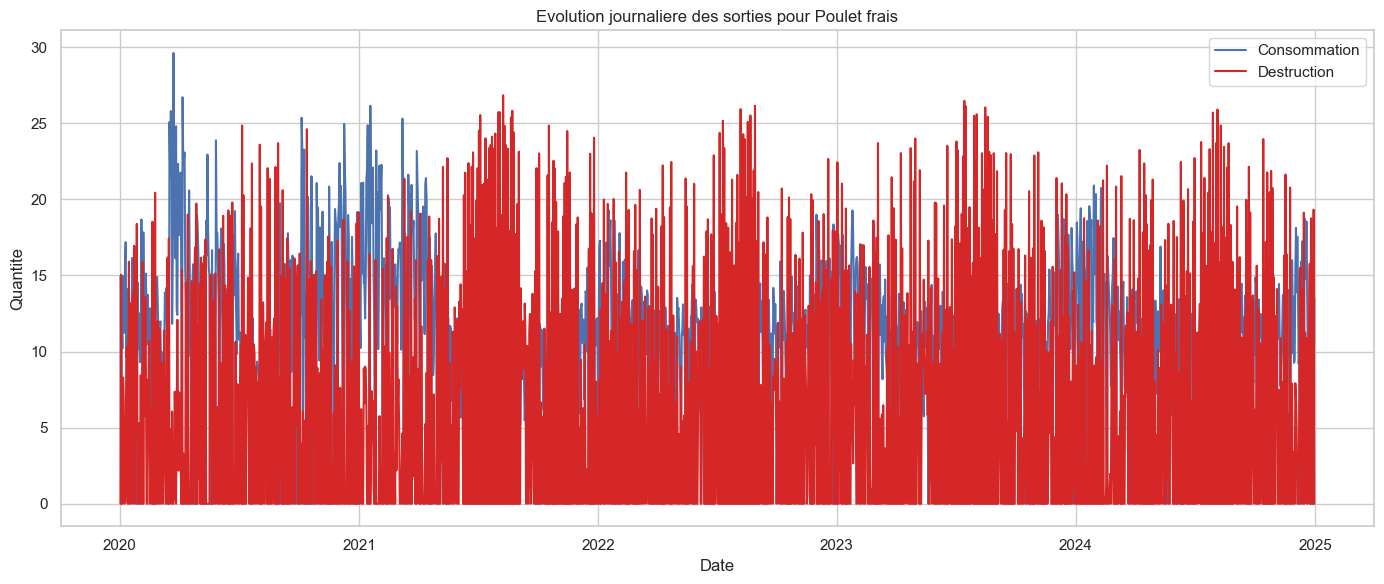

In [15]:
focus_daily = (
    produit_sorties.groupby(['date', 'type_sortie'])['quantite']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

if 'CONSOMMATION' not in focus_daily.columns:
    focus_daily['CONSOMMATION'] = 0
if 'DESTRUCTION' not in focus_daily.columns:
    focus_daily['DESTRUCTION'] = 0

plt.figure(figsize=(14, 6))
sns.lineplot(data=focus_daily, x='date', y='CONSOMMATION', label='Consommation')
sns.lineplot(data=focus_daily, x='date', y='DESTRUCTION', label='Destruction', color='tab:red')
plt.title(f'Evolution journaliere des sorties pour {PRODUIT_FOCUS}')
plt.xlabel('Date')
plt.ylabel('Quantite')
plt.tight_layout()
plt.show()

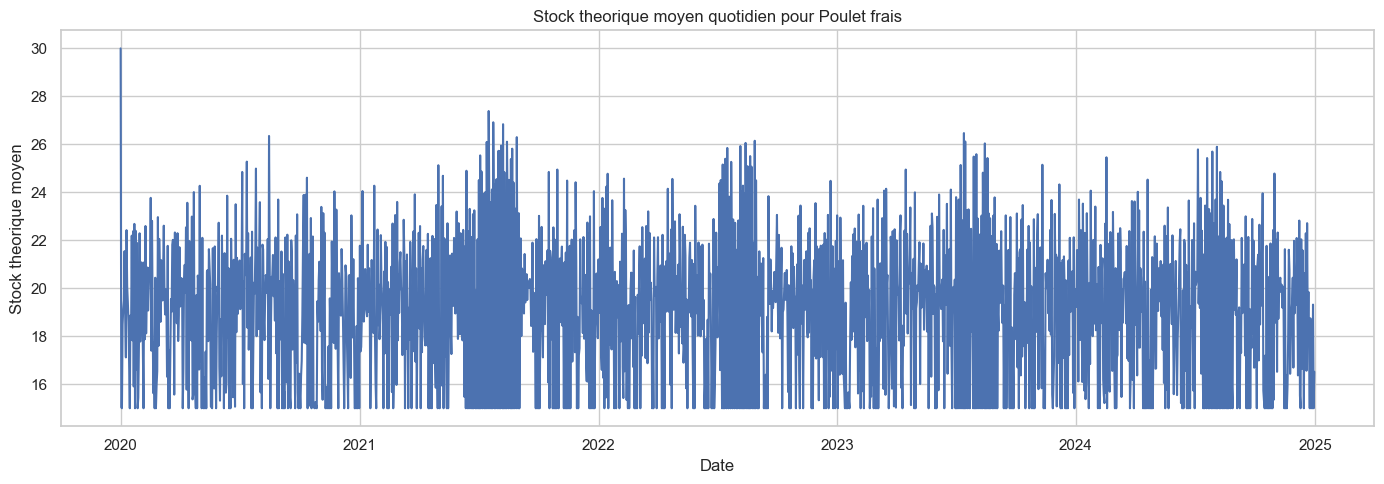

In [16]:
if 'stock_theorique' in produit_df.columns:
    stock_daily = produit_df.groupby('date')['stock_theorique'].mean().reset_index()
    plt.figure(figsize=(14, 5))
    sns.lineplot(data=stock_daily, x='date', y='stock_theorique')
    plt.title(f'Stock theorique moyen quotidien pour {PRODUIT_FOCUS}')
    plt.xlabel('Date')
    plt.ylabel('Stock theorique moyen')
    plt.tight_layout()
    plt.show()
else:
    print('Colonne stock_theorique absente pour le focus produit.')

## 5. Lecture metier rapide

Ce notebook aide a repondre a des questions metier concretes :
- quels produits detruisent le plus en volume
- quels produits ont un taux de gaspillage eleve
- comment evoluent les destructions dans le temps
- si un produit focus semble sous-stocke, sur-stocke ou instable

Pour aller plus loin, tu peux modifier `PRODUIT_FOCUS`, `TOP_N` et `MIN_VOLUME_SORTIE` dans la cellule 2.

## 6. Conclusions et interpretation metier

Cette section synthétise automatiquement les principaux enseignements du notebook a partir des indicateurs calcules plus haut.

Elle vise a transformer les tableaux et graphiques en conclusions directement exploitables pour le pilotage du stock, la limitation du gaspillage et la surveillance des produits sensibles.

In [17]:
top_volume_product = product_kpis['destruction_totale'].idxmax()
top_volume_value = float(product_kpis.loc[top_volume_product, 'destruction_totale'])

top_rate_candidates = product_kpis[product_kpis['sortie_totale'] >= MIN_VOLUME_SORTIE].copy()
if top_rate_candidates.empty:
    top_rate_candidates = product_kpis.copy()

top_rate_product = top_rate_candidates['taux_destruction'].idxmax()
top_rate_value = float(top_rate_candidates.loc[top_rate_product, 'taux_destruction'])

monthly_clean = monthly.replace([np.inf, -np.inf], np.nan).dropna(subset=['taux_destruction']).copy()
if len(monthly_clean) >= 2:
    monthly_clean = monthly_clean.sort_values('date')
    monthly_trend = np.polyfit(np.arange(len(monthly_clean)), monthly_clean['taux_destruction'], 1)[0]
else:
    monthly_trend = 0.0

focus_row = product_kpis.loc[PRODUIT_FOCUS]
focus_rate = float(focus_row['taux_destruction']) if pd.notna(focus_row['taux_destruction']) else 0.0
focus_stock = float(focus_row['stock_moyen']) if pd.notna(focus_row['stock_moyen']) else np.nan
focus_dlc = float(focus_row['dlc_mediane_jours']) if pd.notna(focus_row['dlc_mediane_jours']) else np.nan
focus_conso = float(focus_row['consommation_totale'])
focus_dest = float(focus_row['destruction_totale'])

if monthly_trend > 0.0005:
    trend_comment = "Le taux de destruction mensuel suit une tendance haussiere, ce qui suggere une degradation recente de la maitrise du stock."
elif monthly_trend < -0.0005:
    trend_comment = "Le taux de destruction mensuel suit une tendance baissiere, ce qui suggere une amelioration progressive de la gestion du stock."
else:
    trend_comment = "Le taux de destruction mensuel reste globalement stable sur la periode observee."

if focus_rate >= 0.20:
    focus_comment = f"{PRODUIT_FOCUS} presente un niveau de destruction eleve ({focus_rate:.1%}), ce qui en fait un produit prioritaire a surveiller."
elif focus_rate >= 0.10:
    focus_comment = f"{PRODUIT_FOCUS} presente un niveau de destruction intermediaire ({focus_rate:.1%}) qui merite un suivi regulier."
else:
    focus_comment = f"{PRODUIT_FOCUS} presente un niveau de destruction contenu ({focus_rate:.1%}) au regard des sorties observees."

if pd.notna(focus_dlc) and focus_dlc <= 5:
    dlc_comment = "La DLC mediane courte du produit focus peut expliquer une sensibilite plus forte au gaspillage."
elif pd.notna(focus_dlc) and focus_dlc <= 12:
    dlc_comment = "La DLC mediane du produit focus reste moderee et impose un pilotage stock relativement fin."
else:
    dlc_comment = "La DLC mediane du produit focus laisse plus de marge logistique, ce qui deplace l'attention vers le bon dimensionnement des commandes."

summary_lines = [
    "CONCLUSIONS METIER",
    "=" * 80,
    f"1. Le produit qui detruit le plus en volume est {top_volume_product} avec {top_volume_value:.2f} unites detruites.",
    f"2. Le produit au taux de destruction le plus critique est {top_rate_product} avec un taux de {top_rate_value:.1%} parmi les produits a volume significatif.",
    f"3. Le taux global de destruction du dataset est de {float(global_summary.loc[global_summary['indicateur'] == 'Taux global de destruction', 'valeur'].iloc[0]):.1%}.",
    f"4. {trend_comment}",
    f"5. {focus_comment}",
    f"6. {dlc_comment}",
    f"7. Pour {PRODUIT_FOCUS}, la consommation totale est de {focus_conso:.2f} et la destruction totale de {focus_dest:.2f}.",
]

for line in summary_lines:
    print(line)

conclusions_df = pd.DataFrame(
    {
        'axe': [
            'Produit le plus destructeur en volume',
            'Produit au taux de destruction le plus eleve',
            'Tendance mensuelle du gaspillage',
            'Interpretation produit focus',
            'Lecture logistique du produit focus'
        ],
        'conclusion': [
            f'{top_volume_product} domine les volumes detruits ({top_volume_value:.2f}).',
            f'{top_rate_product} ressort comme le produit le plus critique en taux ({top_rate_value:.1%}).',
            trend_comment,
            focus_comment,
            dlc_comment
        ]
    }
)

display(conclusions_df)

CONCLUSIONS METIER
1. Le produit qui detruit le plus en volume est Pain frais avec 40589.26 unites detruites.
2. Le produit au taux de destruction le plus critique est Saumon frais avec un taux de 82.0% parmi les produits a volume significatif.
3. Le taux global de destruction du dataset est de 17.1%.
4. Le taux de destruction mensuel reste globalement stable sur la periode observee.
5. Poulet frais presente un niveau de destruction eleve (42.0%), ce qui en fait un produit prioritaire a surveiller.
6. La DLC mediane courte du produit focus peut expliquer une sensibilite plus forte au gaspillage.
7. Pour Poulet frais, la consommation totale est de 16126.43 et la destruction totale de 11701.44.


,axe,conclusion
0,Produit le plus destructeur en volume,Pain frais domine les volumes detruits (40589....
1,Produit au taux de destruction le plus eleve,Saumon frais ressort comme le produit le plus ...
2,Tendance mensuelle du gaspillage,Le taux de destruction mensuel reste globaleme...
3,Interpretation produit focus,Poulet frais presente un niveau de destruction...
4,Lecture logistique du produit focus,La DLC mediane courte du produit focus peut ex...
